In [1]:
# Step 1: Import pandas
import pandas as pd

# Step 2: Load CSV from URL
url = 'csv/burial_broken_manual.csv'
df = pd.read_csv(url)

# Step 3: Display the first few rows of the DataFrame
display(df)


,TIME,LABEL
0,14.659048,New Point
1,15.862857,New Point
2,16.259048,New Point
3,16.540952,New Point
4,16.820317,New Point
5,17.244444,New Point
6,17.653333,New Point
7,18.072381,New Point
8,19.276190,New Point
9,19.686168,New Point


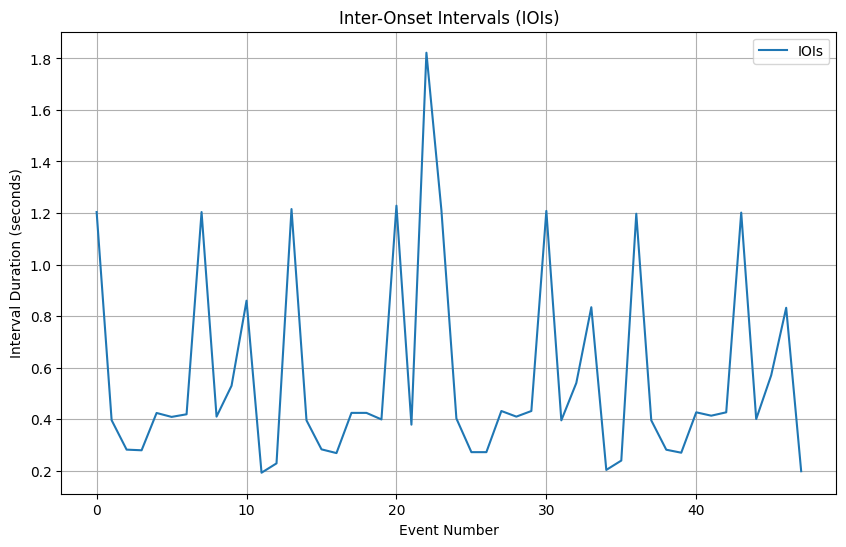

Mean IOI (Average Interval Duration): 0.5655026455000001
Standard Deviation of IOIs: 0.37915521338528735
Coefficient of Variation of IOIs: 0.6704746943315357


In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Onset times in seconds
onset_times = df['TIME'].values

# Calculate inter-onset intervals (IOIs)
iois = np.diff(onset_times)

# Plot the IOIs
plt.figure(figsize=(10, 6))
plt.plot(iois, label="IOIs")
plt.title('Inter-Onset Intervals (IOIs)')
plt.xlabel('Event Number')
plt.ylabel('Interval Duration (seconds)')
plt.grid(True)
plt.legend()
plt.show()

# Calculate standard deviation and coefficient of variation
mean_ioi = np.mean(iois)
std_ioi = np.std(iois)
cv_ioi = std_ioi / mean_ioi  # Coefficient of variation

# Print out results with descriptions
print("Mean IOI (Average Interval Duration):", mean_ioi)
print("Standard Deviation of IOIs:", std_ioi)
print("Coefficient of Variation of IOIs:", cv_ioi)


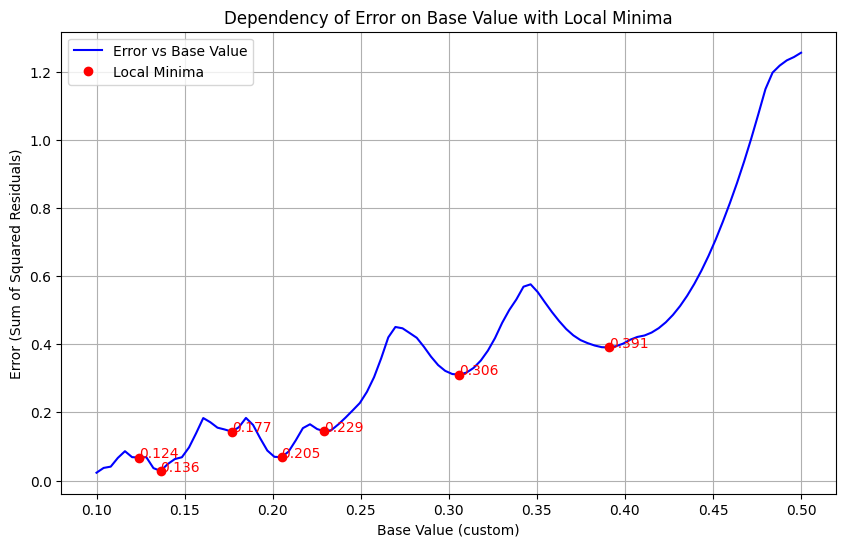

Local minima (base values) and corresponding errors:
Base Value: 0.12424, Error: 0.06754
Base Value: 0.13636, Error: 0.02807
Base Value: 0.17677, Error: 0.14361
Base Value: 0.20505, Error: 0.06855
Base Value: 0.22929, Error: 0.14430
Base Value: 0.30606, Error: 0.31082
Base Value: 0.39091, Error: 0.39048


In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import find_peaks

# Example data (replace with actual data)
data = iois

# Define a range of base values to explore
base_values = np.linspace(0.1, 0.5, 100)  # Adjust range if needed

# Initialize an empty list to store the errors
errors = []

# Loop through different base values and compute the error for each
for base_value_custom in base_values:
    # Calculate multipliers and reconstructed data
    multipliers = np.round(data / base_value_custom)
    reconstructed_data = base_value_custom * multipliers

    # Calculate the residuals and error (sum of squared residuals)
    residuals = data - reconstructed_data
    error = np.sum(residuals**2)

    # Append the error to the list
    errors.append(error)

# Convert errors to a numpy array for further processing
errors = np.array(errors)

# Find local minima (by finding peaks of the negative error array)
minima_indices, _ = find_peaks(-errors)

# Plotting the dependency of the error on the base_value_custom
plt.figure(figsize=(10, 6))
plt.plot(base_values, errors, label='Error vs Base Value', color='blue')

# Mark the local minima
plt.plot(base_values[minima_indices], errors[minima_indices], 'ro', label='Local Minima')

# Annotate the local minima on the plot
for idx in minima_indices:
    plt.text(base_values[idx], errors[idx], f'{base_values[idx]:.3f}', color='red')

plt.title('Dependency of Error on Base Value with Local Minima')
plt.xlabel('Base Value (custom)')
plt.ylabel('Error (Sum of Squared Residuals)')
plt.grid(True)
plt.legend()
plt.show()

# Print out the local minima values
print("Local minima (base values) and corresponding errors:")
for idx in minima_indices:
    print(f"Base Value: {base_values[idx]:.5f}, Error: {errors[idx]:.5f}")


Error (sum of squared residuals): 0.02994052591758082


,Original IOI,Multiplier,Reconstructed IOI,Residual
0,1.203810,9.0,1.215,-0.011190
1,0.396190,3.0,0.405,-0.008810
2,0.281905,2.0,0.270,0.011905
3,0.279365,2.0,0.270,0.009365
4,0.424127,3.0,0.405,0.019127
5,0.408889,3.0,0.405,0.003889
6,0.419048,3.0,0.405,0.014048
7,1.203810,9.0,1.215,-0.011190
8,0.409977,3.0,0.405,0.004977
9,0.529705,4.0,0.540,-0.010295


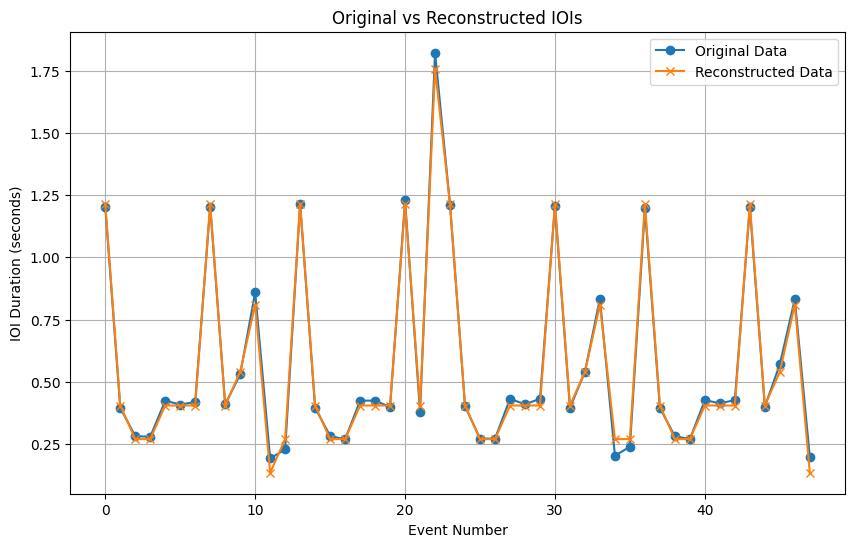

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Example data (replace with actual data)
data = iois

# Custom base value (input your desired base value here)
base_value_custom = 0.135  # Adjust this value as needed

# Calculate multipliers and reconstructed data
multipliers = np.round(data / base_value_custom)
reconstructed_data = base_value_custom * multipliers

# Error calculation (Sum of squared residuals)
residuals = data - reconstructed_data
error = np.sum(residuals**2)

print(f"Error (sum of squared residuals): {error}")

# Create a DataFrame with Original IOI, Multiplier, Reconstructed IOI, Residual
df_results = pd.DataFrame({
    'Original IOI': data,
    'Multiplier': multipliers,
    'Reconstructed IOI': reconstructed_data,
    'Residual': residuals
})

# Display the DataFrame in Colab
display(df_results)

# Plotting
plt.figure(figsize=(10, 6))
plt.plot(data, label='Original Data', marker='o')
plt.plot(reconstructed_data, label='Reconstructed Data', marker='x')
plt.legend()
plt.title('Original vs Reconstructed IOIs')
plt.xlabel('Event Number')
plt.ylabel('IOI Duration (seconds)')
plt.grid(True)
plt.show()


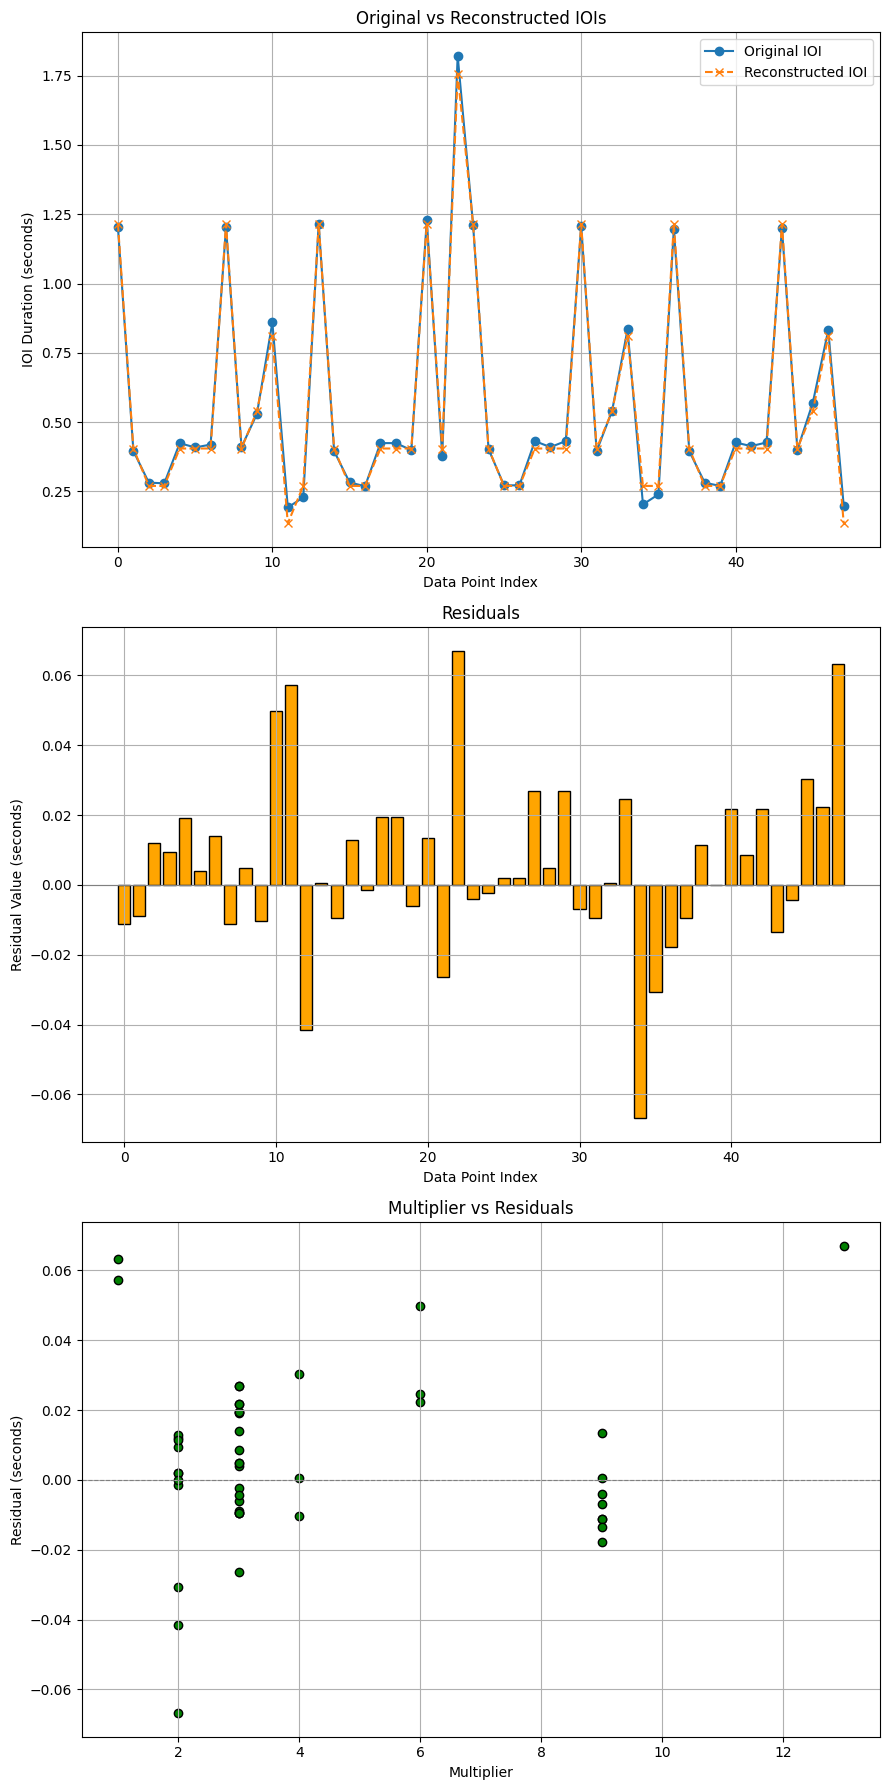

In [5]:
# Plotting Original vs Reconstructed IOIs and other subplots
plt.figure(figsize=(9, 18))  # Adjust figure size for vertical alignment

# Subplot 1: Original vs Reconstructed IOIs
plt.subplot(3, 1, 1)
plt.plot(data, label='Original IOI', marker='o', linestyle='-')
plt.plot(reconstructed_data, label='Reconstructed IOI', marker='x', linestyle='--')
plt.title('Original vs Reconstructed IOIs')
plt.xlabel('Data Point Index')
plt.ylabel('IOI Duration (seconds)')
plt.legend()
plt.grid(True)

# Subplot 2: Residuals
plt.subplot(3, 1, 2)
plt.bar(range(len(residuals)), residuals, color='orange', edgecolor='black')
plt.axhline(0, color='gray', linewidth=0.8)
plt.title('Residuals')
plt.xlabel('Data Point Index')
plt.ylabel('Residual Value (seconds)')
plt.grid(True)

# Subplot 3: Multiplier vs Residuals
plt.subplot(3, 1, 3)
plt.scatter(df_results['Multiplier'], df_results['Residual'], color='green', edgecolor='black')
plt.axhline(0, color='gray', linestyle='--', linewidth=0.8)  # Adding a line at y=0 for reference
plt.title('Multiplier vs Residuals')
plt.xlabel('Multiplier')
plt.ylabel('Residual (seconds)')
plt.grid(True)

plt.tight_layout()
plt.show()

In [6]:
# Step 1: Import pandas
import pandas as pd

# Step 2: Load CSV from URL
url = 'csv/burial_hats.csv'
df2 = pd.read_csv(url)

# Step 3: Display the first few rows of the DataFrame
display(df2)


,TIME,LABEL
0,40.881633,New Point
1,40.950204,New Point
2,41.015510,New Point
3,41.084082,New Point
4,43.785578,New Point
5,43.857415,New Point
6,43.935782,New Point
7,44.007619,New Point
8,44.081633,New Point
9,47.201088,New Point


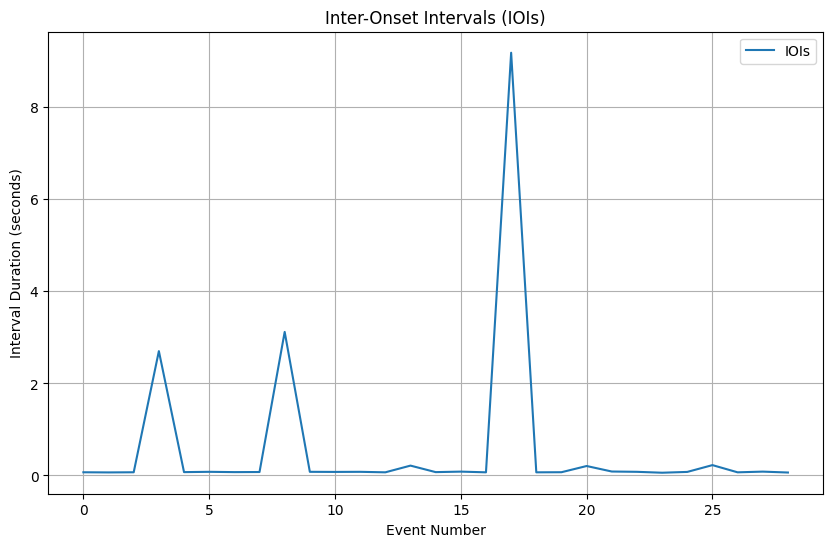

Mean IOI (Average Interval Duration): 0.597213230137931
Standard Deviation of IOIs: 1.7746835530405143
Coefficient of Variation of IOIs: 2.971607900633141


In [7]:
import numpy as np
import matplotlib.pyplot as plt

# Onset times in seconds
onset_times = df2['TIME'].values

# Calculate inter-onset intervals (IOIs)
iois2 = np.diff(onset_times)

# Plot the IOIs
plt.figure(figsize=(10, 6))
plt.plot(iois2, label="IOIs")
plt.title('Inter-Onset Intervals (IOIs)')
plt.xlabel('Event Number')
plt.ylabel('Interval Duration (seconds)')
plt.grid(True)
plt.legend()
plt.show()

# Calculate standard deviation and coefficient of variation
mean_ioi = np.mean(iois2)
std_ioi = np.std(iois2)
cv_ioi = std_ioi / mean_ioi  # Coefficient of variation

# Print out results with descriptions
print("Mean IOI (Average Interval Duration):", mean_ioi)
print("Standard Deviation of IOIs:", std_ioi)
print("Coefficient of Variation of IOIs:", cv_ioi)


In [8]:
display(iois2)

array([0.06857143, 0.06530612, 0.06857143, 2.7014966 , 0.07183673,
       0.07836735, 0.07183674, 0.0740136 , 3.11945578, 0.07836735,
       0.07619048, 0.07836735, 0.06748299, 0.21333333, 0.07183673,
       0.08272109, 0.06748299, 9.18639456, 0.06748299, 0.06965986,
       0.20462585, 0.08489796, 0.07836735, 0.05877551, 0.07619048,
       0.22421769, 0.06748299, 0.08272109, 0.06312925])

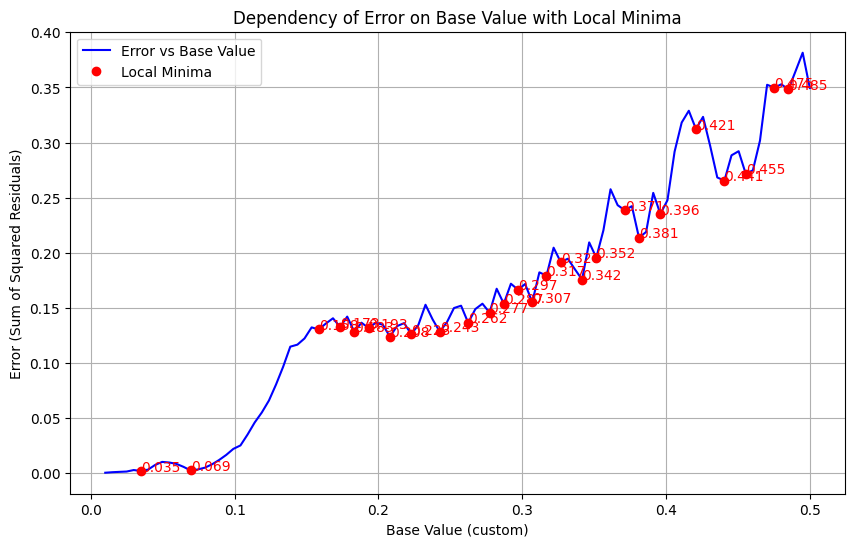

Local minima (base values) and corresponding errors:
Base Value: 0.03475, Error: 0.00181
Base Value: 0.06939, Error: 0.00226
Base Value: 0.15848, Error: 0.13028
Base Value: 0.17333, Error: 0.13253
Base Value: 0.18323, Error: 0.12809
Base Value: 0.19313, Error: 0.13162
Base Value: 0.20798, Error: 0.12376
Base Value: 0.22283, Error: 0.12593
Base Value: 0.24263, Error: 0.12823
Base Value: 0.26242, Error: 0.13626
Base Value: 0.27727, Error: 0.14561
Base Value: 0.28717, Error: 0.15368
Base Value: 0.29707, Error: 0.16637
Base Value: 0.30697, Error: 0.15504
Base Value: 0.31687, Error: 0.17914
Base Value: 0.32677, Error: 0.19147
Base Value: 0.34162, Error: 0.17560
Base Value: 0.35152, Error: 0.19548
Base Value: 0.37131, Error: 0.23854
Base Value: 0.38121, Error: 0.21357
Base Value: 0.39606, Error: 0.23514
Base Value: 0.42081, Error: 0.31228
Base Value: 0.44061, Error: 0.26540
Base Value: 0.45545, Error: 0.27154
Base Value: 0.47525, Error: 0.34987
Base Value: 0.48515, Error: 0.34820


In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import find_peaks

# Example data (replace with actual data)
data = iois2

# Define a range of base values to explore
base_values = np.linspace(0.01, 0.5, 100)  # Adjust range if needed

# Initialize an empty list to store the errors
errors = []

# Loop through different base values and compute the error for each
for base_value_custom in base_values:
    # Calculate multipliers and reconstructed data
    multipliers = np.round(data / base_value_custom)
    reconstructed_data = base_value_custom * multipliers

    # Calculate the residuals and error (sum of squared residuals)
    residuals = data - reconstructed_data
    error = np.sum(residuals**2)

    # Append the error to the list
    errors.append(error)

# Convert errors to a numpy array for further processing
errors = np.array(errors)

# Find local minima (by finding peaks of the negative error array)
minima_indices, _ = find_peaks(-errors)

# Plotting the dependency of the error on the base_value_custom
plt.figure(figsize=(10, 6))
plt.plot(base_values, errors, label='Error vs Base Value', color='blue')

# Mark the local minima
plt.plot(base_values[minima_indices], errors[minima_indices], 'ro', label='Local Minima')

# Annotate the local minima on the plot
for idx in minima_indices:
    plt.text(base_values[idx], errors[idx], f'{base_values[idx]:.3f}', color='red')

plt.title('Dependency of Error on Base Value with Local Minima')
plt.xlabel('Base Value (custom)')
plt.ylabel('Error (Sum of Squared Residuals)')
plt.grid(True)
plt.legend()
plt.show()

# Print out the local minima values
print("Local minima (base values) and corresponding errors:")
for idx in minima_indices:
    print(f"Base Value: {base_values[idx]:.5f}, Error: {errors[idx]:.5f}")
